In [1]:
import numpy as np
import pymcel as pc
import rebound as rb

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [35]:
sim_solar=rb.Simulation()
rb.horizons.SSL_CONTEXT = 'unverified' ##Se pone por un asunto de seguridad, pues el sitio debe ser no seguro
fecha='2029-04-01'
sim_solar.add('Sun', date=fecha) # Sol
#sim_solar.add('Mercury', date=fecha) # Mercurio
#sim_solar.add('Venus', date=fecha) # Venus
sim_solar.add('Earth', date=fecha) # Tierra
#sim_solar.add('Moon' ,date=fecha) # Luna
#sim_solar.add('Mars', date=fecha) # Marte
#sim_solar.add('Jupiter', date=fecha) # Júpiter
#sim_solar.add('Saturn', date=fecha) # Saturno
#sim_solar.add('Neptune', date=fecha) # Neptuno
#sim_solar.add('Uranus', date=fecha) # Urano
sim_solar.add('99942', date=fecha) # Apophis


Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for '99942'... 
Found: 99942 Apophis (2004 MN4) 


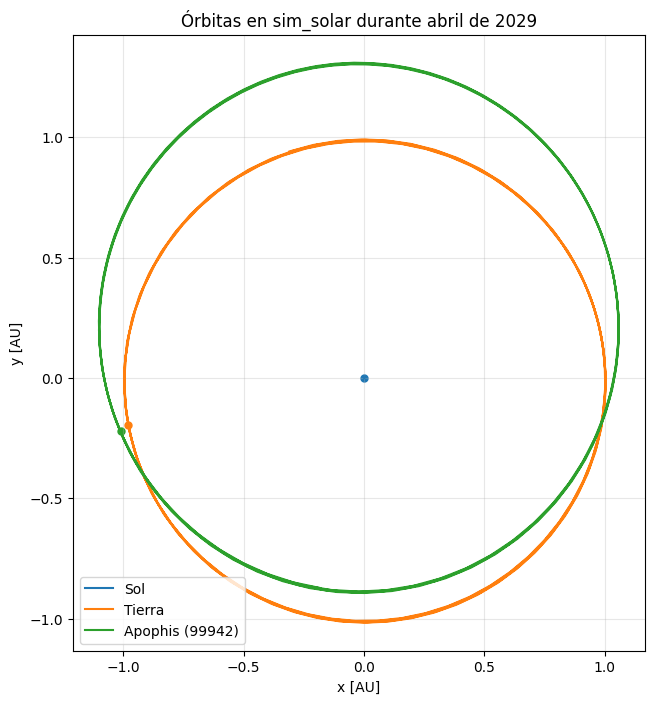

In [36]:
import matplotlib.pyplot as plt

# Si los estados vienen como NaN, reconstruimos la simulación base
if not np.isfinite([p.x for p in sim_solar.particles]).all():
    sim_solar = rb.Simulation()
    rb.horizons.SSL_CONTEXT = "unverified"
    sim_solar.add("Sun", date=fecha)
    sim_solar.add("Earth", date=fecha)
    sim_solar.add("99942", date=fecha)

# Copia para no modificar sim_solar original
sim_mes = sim_solar.copy()

# Abril 2029: 30 días desde 2029-04-01
tiempos_dias = np.linspace(0, 30, 301)

n = sim_mes.N
x = np.zeros((n, len(tiempos_dias)))
y = np.zeros((n, len(tiempos_dias)))

for j, td in enumerate(tiempos_dias):
    sim_mes.integrate(td, exact_finish_time=1)
    for i, p in enumerate(sim_mes.particles):
        x[i, j] = p.x
        y[i, j] = p.y

labels = ["Sol", "Tierra", "Apophis (99942)"][:n]

plt.figure(figsize=(8, 8))
for i in range(n):
    plt.plot(x[i], y[i], label=labels[i])
    plt.scatter(x[i, 0], y[i, 0], s=25)  # posición inicial

plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x [AU]")
plt.ylabel("y [AU]")
plt.title("Órbitas en sim_solar durante abril de 2029")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<rebound.particle.Particle object at 0x22b5f2254d0, m=3.2271560828978514e-07 x=nan y=nan z=nan vx=nan vy=nan vz=nan>
